# E. Coli Random Walk Model

## Pure Random Walk
This section will model a pure random walk with no attractor.

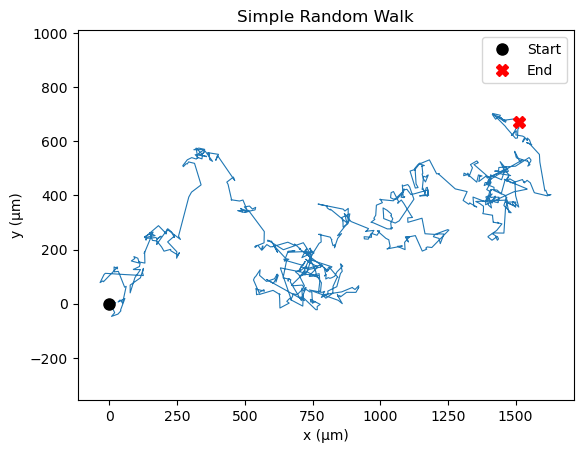

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import math

# --- Base Parameters ---
np.random.seed(371)   # Determines randomness
speed = 20            # Unit: micrometre/second
run_duration = 1.0    # Mean time cell runs (seconds)
tumble_duration = 0.1 # Mean time cell tumbles (seconds)
total_duration = 1000  # Total simulation runtime (seconds)

# --- Cell Run & Tumble ---
position = np.array([0.0,0.0]) 
path = [position.copy()]
t = 0

angle = np.random.uniform(0, 2*math.pi) #Starting direction

while t < total_duration:
    # RUN: Move in direction of angle for random duration
    run_time = np.random.exponential(run_duration)
    position += np.array([math.cos(angle), math.sin(angle)]) * speed * run_time

    # TUMBLE: New direction
    angle = np.random.uniform(0, 2 * math.pi)
    tumble_time = np.random.exponential(tumble_duration)

    t += run_time + tumble_time
    path.append(position.copy())

# --- Plotting ---
path = np.array(path)

plt.plot(path[:, 0], path[:, 1], lw=0.8)
plt.plot(0, 0, 'ko', markersize=8, label='Start')
plt.plot(path[-1, 0], path[-1, 1], "X",color='red', markersize=8, label='End')
plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.title("Simple Random Walk")
plt.legend()
plt.axis('equal')
plt.savefig("random_walk.png", dpi=400, bbox_inches="tight")
plt.show()


## Pure Random Walk & Attractant Concentration
This section incorporates a gradient attractant: for E. coli, the attractant is sugar, which provides it with energy. However, E. coli cells don't yet respond to this attractant in this model. This serves as a baseline for the following model when cell behaviour is introduced


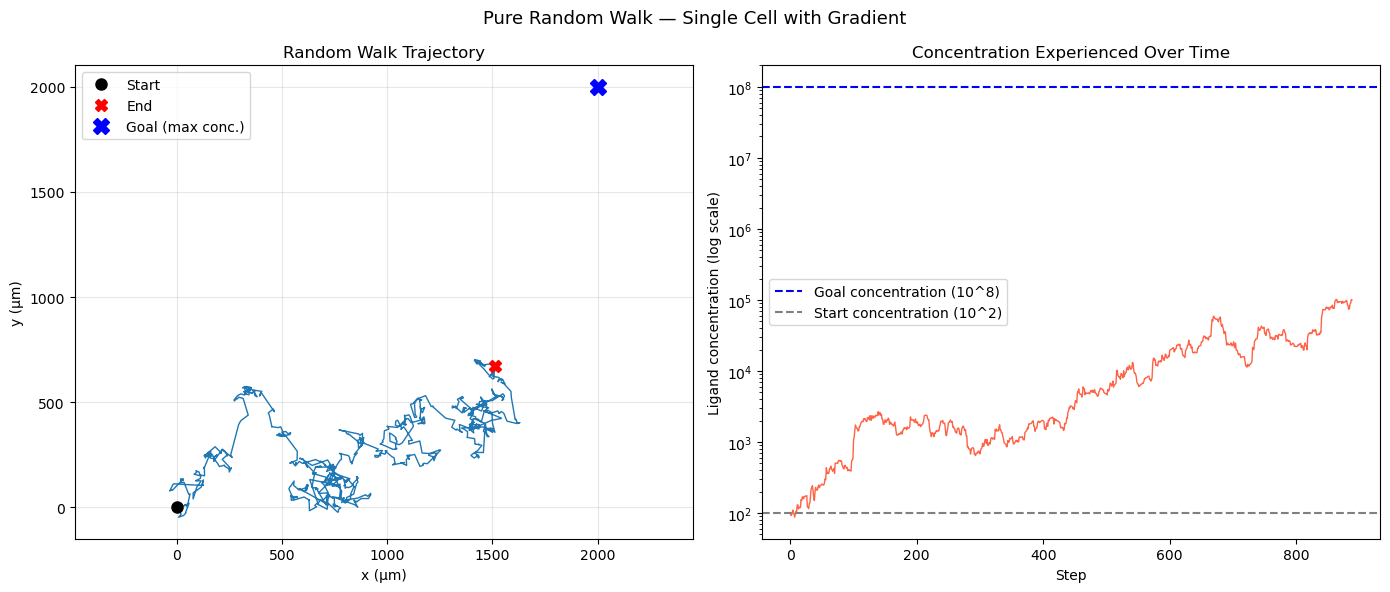

Final position : (1511.7, 671.5) µm
Distance to goal: 1415.4 µm  (goal is at 2828.4 µm from start)
Final concentration : 9.94e+04  (goal = 1.00e+08)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math

# --- Base Parameters ---
np.random.seed(371)   # Determines randomness
speed = 20            # Unit: micrometre/second
run_duration = 1.0    # Mean time cell runs (seconds)
tumble_duration = 0.1 # Mean time cell tumbles (seconds)
total_duration = 1000  # Total simulation runtime (seconds)

# --- Location & Concentration ---
start = [0.0, 0.0]
goal = [2000.0, 2000.0] # Highest concentration point
start_exponent = 2
goal_exponent = 8

# --- Distance & Concentration Functions ---

# Euclidean distance

def distance(a,b):
    return math.sqrt((a[0] - b[0])**2 + (a[1]-b[1])**2)
    
# Concentration calculation w.r.t distance from origin to center

def calculate_concentration(pos, origin_to_center):
    dist = distance(pos, goal)
    exponent = (1 - dist / origin_to_center) * (goal_exponent - start_exponent) + start_exponent
    return 10 ** exponent

# --- Cell Simulation ---

# --- Core simulation function ---
def simulate_one_cell(duration, run_time_mu, seed=None):
    """
        Parameters:
        duration    : int   - how many seconds to run the simulation
        run_time_mu : float - mean run duration before tumbling (seconds)
        seed        : int   - random seed for reproducibility (optional)

    Returns:
        path        : list of [x, y] positions recorded at each step
        concentration_path   : list of ligand concentrations at each recorded position
    """
    if seed is not None:
        np.random.seed(371)

    origin_to_center = distance(start, goal)
    position = np.array(start, dtype=float)
    angle = np.random.uniform(0, 2 * math.pi)

    path = [position.copy()]
    concentration_path = [calculate_concentration(position, origin_to_center)]

    t = 0
    while t < duration:
        # RUN
        run_time = np.random.exponential(run_time_mu)
        position += np.array([math.cos(angle), math.sin(angle)]) * speed * run_time

        # Record position and concentration after each run
        path.append(position.copy())
        concentration_path.append(calculate_concentration(position, origin_to_center))

        # TUMBLE
        angle = np.random.uniform(0, 2 * math.pi)
        tumble_time = np.random.exponential(tumble_duration)

        t += run_time + tumble_time

    return path, concentration_path

# --- Run and plot ---
path, concentration_path = simulate_one_cell(duration=1000, run_time_mu=1.0, seed=371)
path = np.array(path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: trajectory
ax1.plot(path[:, 0], path[:, 1], lw=1, alpha=1)
ax1.plot(*start, 'ko', markersize=8, label='Start')
ax1.plot(*path[-1], 'rX', markersize=8, label='End')
ax1.plot(*goal, 'bX', markersize=12, label='Goal (max conc.)')
ax1.set_xlabel("x (µm)")
ax1.set_ylabel("y (µm)")
ax1.set_title("Random Walk Trajectory")
ax1.legend()
ax1.axis('equal')
ax1.grid(alpha=0.3)

# Right plot: concentration over time
ax2.plot(concentration_path, color='tomato', lw=1)
ax2.set_yscale('log')                          # log scale since range is 10^2 to 10^8
ax2.axhline(y=10**8, color='blue', linestyle='--', label='Goal concentration (10^8)')
ax2.axhline(y=10**2, color='gray', linestyle='--', label='Start concentration (10^2)')
ax2.set_xlabel("Step")
ax2.set_ylabel("Ligand concentration (log scale)")
ax2.set_title("Concentration Experienced Over Time")
ax2.legend()


plt.suptitle("Pure Random Walk — Single Cell with Gradient", fontsize=13)
plt.tight_layout()
plt.savefig("random_walk_gradient.png", dpi=400, bbox_inches="tight")
plt.show()

# Print summary stats
final_dist = distance(path[-1], goal)
final_conc = concentration_path[-1]
print(f"Final position : ({path[-1,0]:.1f}, {path[-1,1]:.1f}) µm")
print(f"Distance to goal: {final_dist:.1f} µm  (goal is at {distance(start, goal):.1f} µm from start)")
print(f"Final concentration : {final_conc:.2e}  (goal = 1.00e+08)")


